In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#matplotlib inline

In [2]:
from sklearn.datasets import make_blobs #makes isotropic gausian blobs for clustering

In [3]:
x,y = make_blobs(n_samples=1000,centers=3 , n_features= 2 ,random_state= 24)

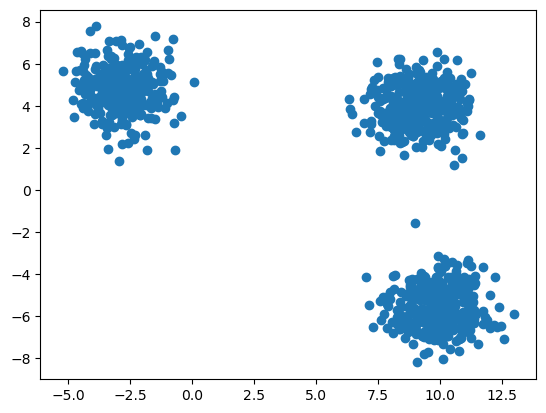

In [4]:
plt.scatter(
    x[:,0],
    x[:,1],
)

In [5]:
from sklearn.model_selection import train_test_split as tts 
x_train,x_test,y_train,y_test = tts(x,y, test_size= 0.23,random_state=11)

In [6]:
from sklearn.cluster import KMeans

In [7]:
#using the elbow method to get the k value
wcss = []
for k in range(1,15):
    kmeans = KMeans(n_clusters= k, init= "k-means++") # make sure the random points are properly distanced
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

In [8]:
wcss

[45189.57540789918,
 13441.216872994308,
 1496.1802989941564,
 1299.3759448947808,
 1154.5708888642048,
 1036.835884570632,
 883.5783616013238,
 800.069281788968,
 661.6790103391187,
 630.4247507309199,
 560.3341247462567,
 517.5633622528943,
 483.2192984716212,
 458.83103331589166]

<function matplotlib.pyplot.show(close=None, block=None)>

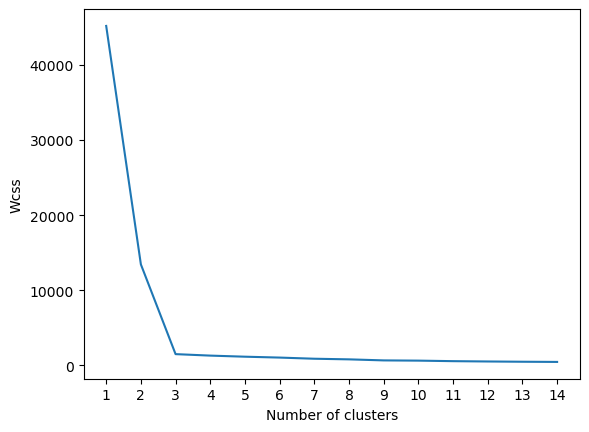

In [9]:
plt.plot(range(1,15),wcss)
plt.xticks(range(1,15))
plt.xlabel("Number of clusters")
plt.ylabel("Wcss")
plt.show

manual observations shows that k = 3 is ideal and after that the clusters stablizes

In [10]:
y_labels = kmeans.fit_predict(x_train) # to find out labels for x train data

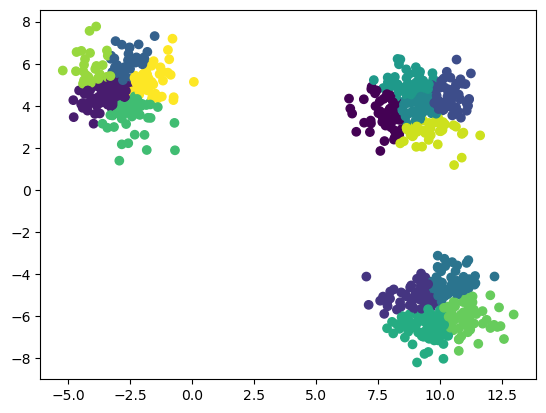

In [11]:
plt.scatter(
    x_train[:,0],
    x_train[:,1],
    c= y_labels
)

In [12]:
y_test_labels = kmeans.predict(x_test)

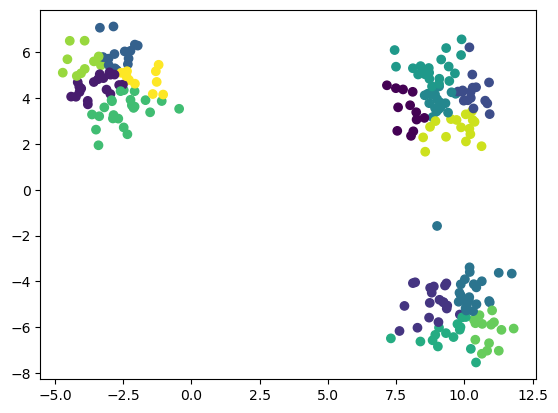

In [13]:
plt.scatter(
    x_test[:,0],
    x_test[:,1],
    c= y_test_labels
)

In [ ]:
#to automate all these things just to find k 
%pip install kneed

In [ ]:
from kneed import KneeLocator

In [ ]:
k1 = KneeLocator(range(1,15),wcss,curve = "convex", direction = "decreasing")
k1.elbow

3

In [ ]:
#performace metrics
from sklearn.metrics import silhouette_score
silhouette_coeff = []
for k in range(2,15):
    kmeans = KMeans(n_clusters= k, init= "k-means++") # make sure the random points are properly distanced
    kmeans.fit(x_train)
    score = silhouette_score(x_train,kmeans.labels_)
    silhouette_coeff.append(score)

In [ ]:
silhouette_coeff

[0.6832580027792733,
 0.8296685929546626,
 0.6415165249155357,
 0.48363848614177185,
 0.31887838819486947,
 0.3144529636213673,
 0.3318560401665183,
 0.3325188185001556,
 0.3328332830059783,
 0.3266672345203868,
 0.3191730633914733,
 0.31963585454215837,
 0.3148567038933514]

<function matplotlib.pyplot.show(close=None, block=None)>

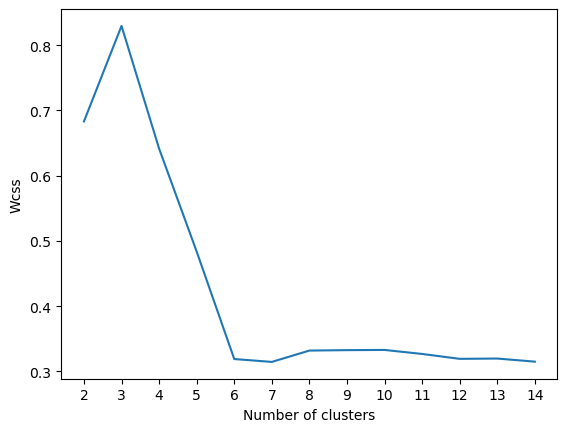

In [ ]:
plt.plot(range(2,15),silhouette_coeff)
plt.xticks(range(2,15))
plt.xlabel("Number of clusters")
plt.ylabel("Wcss")
plt.show

Peak at k = 3